# Future Stock price prediction model

## Data collection

In [1]:
!pip install yfinance

In [1]:
import yfinance as yf
import pandas as pd

In [2]:
df = yf.download('AAPL', start='2015-01-01', end='2026-04-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
df.to_csv('stock_data.csv')  # save once
df = pd.read_csv('stock_data.csv', index_col=0)  # load next time

In [4]:
df

,Close,High,Low,Open,Volume
Price,,,,,
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,NaN,NaN,NaN,NaN,NaN
2015-01-02,24.214889526367188,24.682221739158916,23.7763496768566,24.671146843393636,212818400
2015-01-05,23.532716751098633,24.064279632140636,23.34667067211943,23.984545115494743,257142000
2015-01-06,23.534936904907227,23.794073292366384,23.173916188735014,23.59695227731193,263188400
...,...,...,...,...,...
2026-03-25,252.6199951171875,255.0,251.60000610351562,254.10000610351562,28476700
2026-03-26,252.88999938964844,257.0,250.77000427246094,252.1199951171875,41796700
2026-03-27,248.8000030517578,255.49000549316406,248.07000732421875,253.89999389648438,47900000


## Exploratory Data Analysis

### Step 1 — Basic Info

In [5]:
df.head()

,Close,High,Low,Open,Volume
Price,,,,,
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,NaN,NaN,NaN,NaN,NaN
2015-01-02,24.214889526367188,24.682221739158916,23.7763496768566,24.671146843393636,212818400
2015-01-05,23.532716751098633,24.064279632140636,23.34667067211943,23.984545115494743,257142000
2015-01-06,23.534936904907227,23.794073292366384,23.173916188735014,23.59695227731193,263188400


In [6]:
df.tail()

,Close,High,Low,Open,Volume
Price,,,,,
2026-03-25,252.6199951171875,255.0,251.60000610351562,254.10000610351562,28476700
2026-03-26,252.88999938964844,257.0,250.77000427246094,252.1199951171875,41796700
2026-03-27,248.8000030517578,255.49000549316406,248.07000732421875,253.89999389648438,47900000
2026-03-30,246.6300048828125,250.8699951171875,245.50999450683594,250.07000732421875,39446200
2026-03-31,253.7899932861328,255.47999572753906,247.10000610351562,247.91000366210938,49598100


In [7]:
print(df.shape)

(2829, 5)


In [8]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [9]:
print(df.info())       # data types and null counts

<class 'pandas.core.frame.DataFrame'>
Index: 2829 entries, Ticker to 2026-03-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Close   2828 non-null   object
 1   High    2828 non-null   object
 2   Low     2828 non-null   object
 3   Open    2828 non-null   object
 4   Volume  2828 non-null   object
dtypes: object(5)
memory usage: 132.6+ KB
None


In [10]:
print(df.dtypes)       # column data types

Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object


Since all features are currently of type object, they are first converted to an appropriate numerical format (float) to enable effective quantitative analysis and model processing.

In [11]:
df = df[df.index != 'Ticker']

# Step 2 — Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

In [12]:
print(df.dtypes)
print(df.head())

Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object
                Close       High        Low       Open       Volume
Price                                                              
Date              NaN        NaN        NaN        NaN          NaN
2015-01-02  24.214890  24.682222  23.776350  24.671147  212818400.0
2015-01-05  23.532717  24.064280  23.346671  23.984545  257142000.0
2015-01-06  23.534937  23.794073  23.173916  23.596952  263188400.0
2015-01-07  23.864954  23.964621  23.632395  23.743137  160423600.0


### Step 2 — Basic Statistics

In [13]:
print(df.describe())

             Close         High          Low         Open        Volume
count  2827.000000  2827.000000  2827.000000  2827.000000  2.827000e+03
mean    109.546622   110.643106   108.357707   109.459769  1.100317e+08
std      76.787043    77.541572    75.980293    76.731519  6.797006e+07
min      20.584814    20.887868    20.386578    20.507344  1.791060e+07
25%      37.048939    37.414642    36.638091    37.037937  6.320525e+07
50%     106.663757   108.727410   105.040495   106.523571  9.325140e+07
75%     171.025604   172.059991   168.816227   170.530581  1.359192e+08
max     285.922455   288.350192   283.035157   285.932471  6.488252e+08


### Step 3 — Check Missing Values

In [14]:
df.isnull().sum()

Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

This dataset has one null-row so we have to drop this row

In [15]:
df=df.dropna()
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [16]:
df.shape

(2827, 5)

In [17]:
print(df.index)
print(type(df.index))

Index(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
       '2015-01-09', '2015-01-12', '2015-01-13', '2015-01-14', '2015-01-15',
       ...
       '2026-03-18', '2026-03-19', '2026-03-20', '2026-03-23', '2026-03-24',
       '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31'],
      dtype='object', name='Price', length=2827)
<class 'pandas.core.indexes.base.Index'>


In [18]:
# # Remove the first row where 'Date' is sitting as a value
df = df.iloc[1:]

# # Convert index to proper datetime
df.index = pd.to_datetime(df.index)

# # Convert columns to numeric (they may be stored as strings)
df = df.apply(pd.to_numeric)

print(df.index)
print(df.dtypes)
print(df.head())

DatetimeIndex(['2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-12', '2015-01-13', '2015-01-14',
               '2015-01-15', '2015-01-16',
               ...
               '2026-03-18', '2026-03-19', '2026-03-20', '2026-03-23',
               '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27',
               '2026-03-30', '2026-03-31'],
              dtype='datetime64[ns]', name='Price', length=2826, freq=None)
Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object
                Close       High        Low       Open       Volume
Price                                                              
2015-01-05  23.532717  24.064280  23.346671  23.984545  257142000.0
2015-01-06  23.534937  23.794073  23.173916  23.596952  263188400.0
2015-01-07  23.864954  23.964621  23.632395  23.743137  160423600.0
2015-01-08  24.781891  24.839477  24.075355  24.192743  237458000.0
2015-01-09  24.808479 

### AAPL Closing Price (2015–2026)

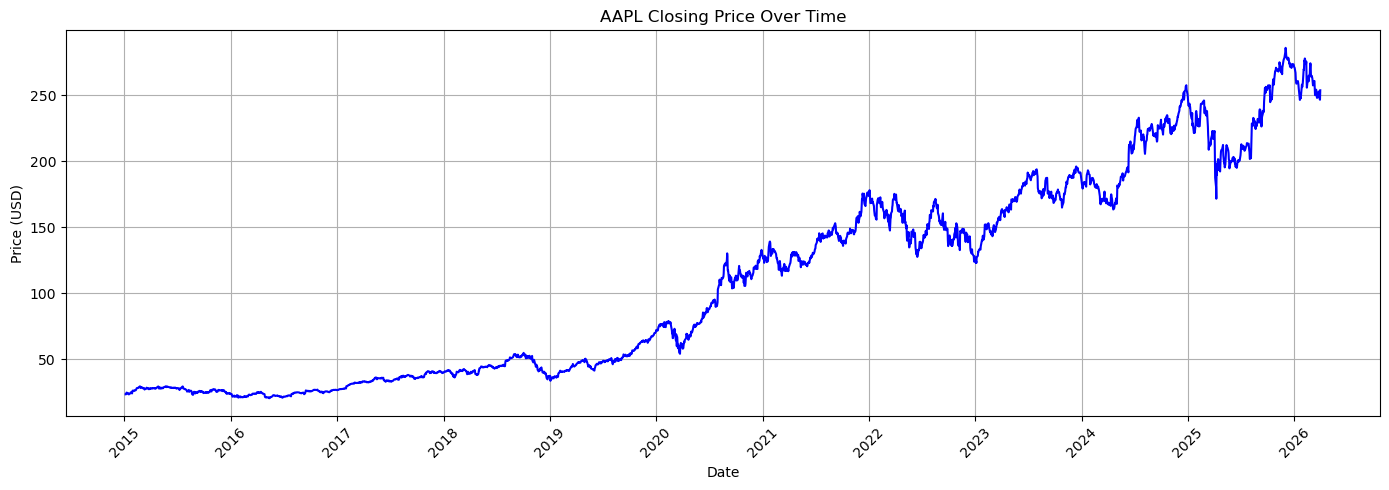

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], color='blue')
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# This fixes the date visibility
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

#### Analytical Summary 
Apple Inc. (AAPL) showed strong long-term growth from 2015 to 2026, increasing लगभग ~8x from ~$30 to a peak near ~$280 (late 2024/early 2025).

From 2015–2019, the stock rose steadily with low volatility, reflecting stable investor confidence. In early 2020, AAPL experienced a sharp COVID-19-related dip but recovered quickly—faster than the broader market—highlighting strong fundamentals.

The most significant growth occurred between 2020–2022, where the price tripled (~$55 → ~$180), driven by product cycles and services expansion. This was followed by a ~33% correction in 2022–2023 (down to ~$120) due to macroeconomic pressures like rising interest rates and a broader tech sector reset.

From 2023 onward, AAPL rebounded strongly, surpassing previous highs and reaching ~$280, before a mild pullback to ~$250 toward the end, likely due to profit-taking or market uncertainty.

Overall, AAPL demonstrates resilience, consistent recovery from downturns, and sustained upward momentum, making it well-suited for long-term trend analysis and forecasting.

### AAPL Trading Volume (2015–2026)

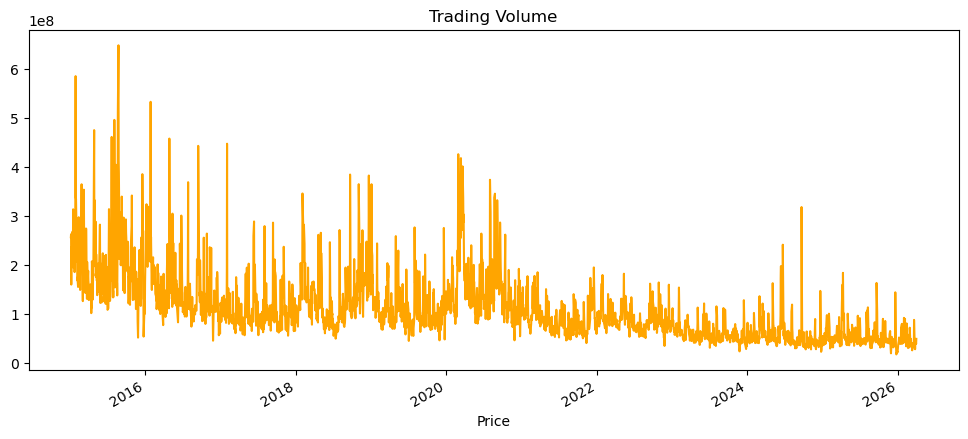

In [20]:
df['Volume'].plot(figsize=(12,5), title='Trading Volume', color='orange')
plt.show()

#### Analytical Summary 

AAPL’s trading volume shows a clear long-term decline, contrasting with its rising price. In 2015–2016, volume often exceeded 600M shares, driven by strong retail speculation and uncertainty about Apple’s growth.

From 2017–2019, volume remained high but gradually stabilized. A sharp spike occurred in early 2020 during the COVID-19 market panic as investors rapidly adjusted positions.

After 2021, volume steadily declined, falling below 100M shares on most days by 2024–2026. This inverse relationship between rising price and falling volume suggests a shift from speculative trading to a more stable, institutionally held stock.

Overall, the trend reflects increasing market maturity and stronger investor conviction, with long-term holders dominating over short-term traders.

### AAPL Daily Returns (2015–2026)

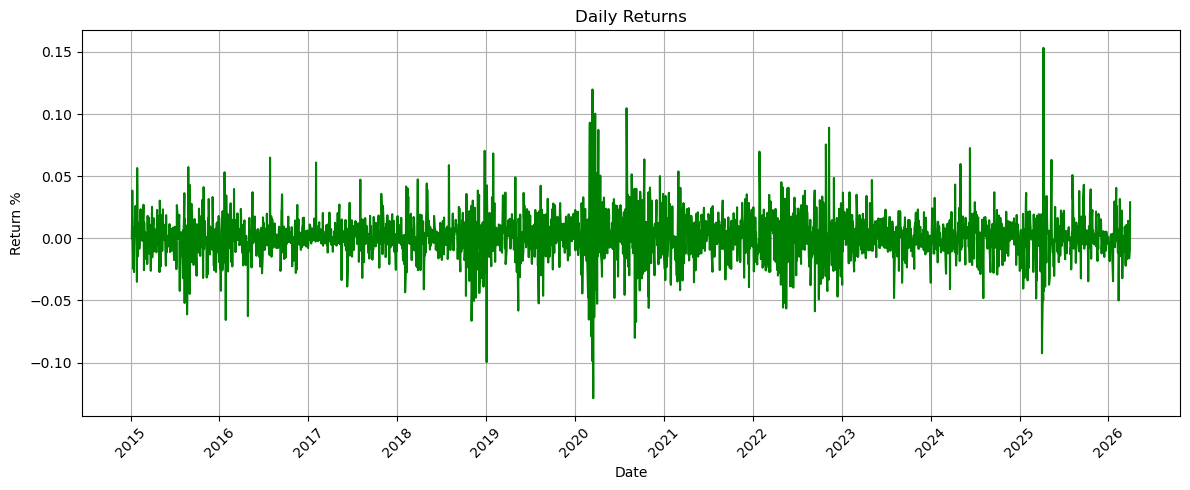

In [21]:
df['Daily Return'] = df['Close'].pct_change()

plt.figure(figsize=(12,5))
plt.plot(df['Daily Return'], color='green')
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return %')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()

plt.grid(True)
plt.show()

#### Analytical Summary 
AAPL's daily returns chart exhibits a pattern consistent with stationary, mean-reverting behavior — the returns consistently fluctuate around zero throughout the entire period, which is characteristic of an efficient, liquid stock.

For the majority of the observed period (2015–2019), daily returns remained tightly clustered within a ±2–3% range, indicating low volatility and steady market conditions. This period reflects investor confidence with no major macro disruptions.

The most significant volatility cluster appears in early 2020, where daily swings exceeded ±10%, directly attributable to COVID-19 driven market panic and rapid recovery. This represents the highest volatility episode in the dataset and is a textbook example of an external shock causing temporary deviation from normal return distribution.

Post-2020, returns normalized back to the ±3–5% range. However, two notable outliers stand out in 2025 — a single-day gain exceeding +15% and a sharp loss of approximately -10%, likely triggered by major earnings announcements or macroeconomic events.

Overall, the return distribution suggests low average daily movement with occasional fat-tail events, which aligns with a leptokurtic distribution — a common and well-documented characteristic of stock return data. This has direct implications for risk modeling, where standard normal distribution assumptions would underestimate tail risk.

### Close Price with Moving Averages (2015–2026)

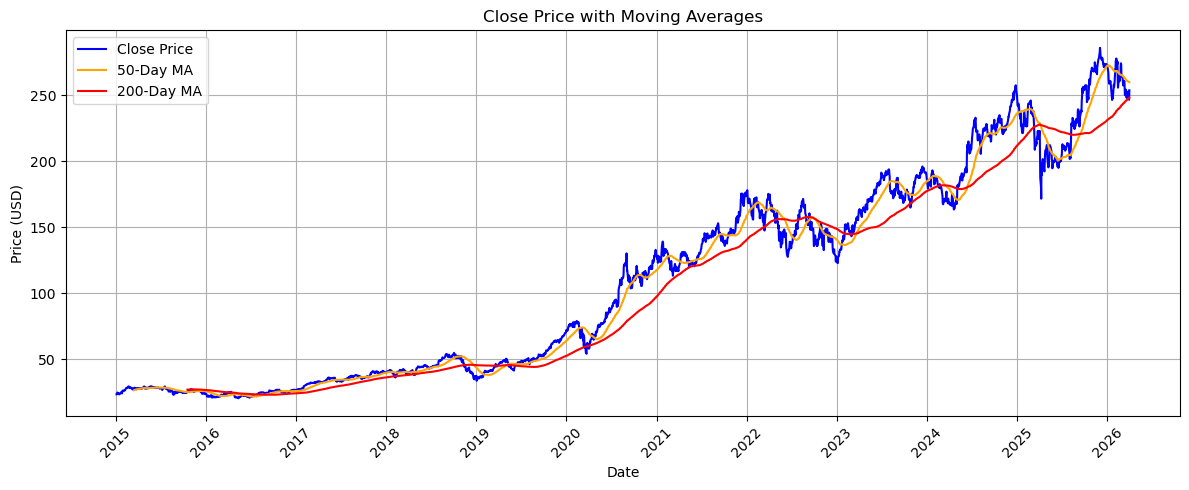

In [22]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.plot(df['MA50'], label='50-Day MA', color='orange')
plt.plot(df['MA200'], label='200-Day MA', color='red')
plt.title('Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()

plt.legend()
plt.grid(True)
plt.show()

#### Analytical Summary 
The chart overlays AAPL's daily closing price with its 50-day and 200-day Simple Moving Averages, providing a comprehensive view of both short-term momentum and long-term trend direction.

Throughout 2015–2019, all three lines moved closely together within a narrow price range, reflecting a low-volatility, gradually trending market. The tight convergence of both MAs during this period confirms the absence of any strong directional momentum.

A key inflection point occurs in 2020, where the price sharply broke above both moving averages following the COVID recovery — a classic bullish breakout signal. The 50-day MA subsequently crossed above the 200-day MA, forming a Golden Cross, which technically confirmed the beginning of a strong uptrend that sustained through 2022.

During the 2022–2023 correction, the blue price line dipped below the 50-day MA and briefly tested the 200-day MA as support — a critical technical level. The fact that the 200-day MA held as support and price bounced back is a strong indicator of the underlying long-term bullish structure remaining intact.

From 2023 to 2025, price consistently traded above both MAs, confirming continued bullish momentum. Near the end of 2025, the price dropped sharply and briefly crossed below both MAs, which could signal a potential trend reversal or consolidation phase — a key area of concern for forward-looking analysis.

Overall, the moving average analysis confirms AAPL's dominant long-term uptrend, with the 200-day MA consistently acting as a reliable dynamic support level throughout the observed period.

### Correlation Between Columns

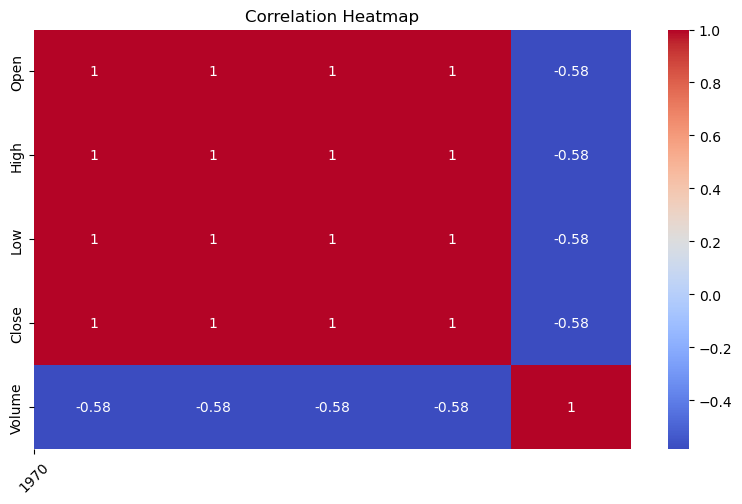

In [23]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), 
            annot=True, cmap='coolwarm')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()

plt.title('Correlation Heatmap')
plt.show()

#### Analytical Summary
The first and most prominent finding is the perfect correlation (1.0) among all four price-based variables — Open, High, Low, and Close. This is expected, as all four metrics are derived from the same underlying asset price and move in near-perfect unison over time. This confirms that for modeling purposes, using all four price columns simultaneously would introduce multicollinearity, and a single price variable (typically Close) is sufficient to represent price movement.

The second key finding is the moderate negative correlation (-0.58) between Volume and all price columns. This inverse relationship corroborates the earlier volume analysis — as AAPL's price rose significantly over the years, trading volume steadily declined. This suggests that the stock's price appreciation was driven more by long-term institutional holding and reduced selling pressure rather than high-frequency speculative trading.

## Building LSTM models

In [25]:
!pip install tensorflow

In [24]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Daily Return', 'MA50',
       'MA200'],
      dtype='object')

In [25]:
data = df[['Close']].values
print(data.shape)

(2826, 1)


In [26]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from sklearn.preprocessing import MinMaxScaler

### Scale the data

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

print(scaled_data.min())  # should be 0
print(scaled_data.max())  # should be 1

0.0
1.0


### Train the data

In [28]:
# 80% training, 20% testing
train_size = int(len(scaled_data) * 0.80)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f'Train size: {len(train_data)}')
print(f'Test size: {len(test_data)}')

Train size: 2260
Test size: 566


In [29]:
X_train_data, y_train_data = [], []

In [30]:
for i in range(90, len(train_data)):
    X_train_data.append(train_data[i-90:i, 0])
    y_train_data.append(train_data[i,0])

In [31]:
import numpy as np
X_train_data, y_train_data = np.array(X_train_data), np.array(y_train_data)
X_train_data = np.reshape(X_train_data, (X_train_data.shape[0], X_train_data.shape[1], 1))

### Building LSTM model

In [32]:
lstm_model=Sequential()
lstm_model.add(LSTM(units=150,return_sequences=True,input_shape=(X_train_data.shape[1],1)))
lstm_model.add(LSTM(units=150))
lstm_model.add(Dense(1))

C:\Users\freel\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
# ── STEP 1: Compile ──────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 90, 150)             │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             151 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,951 (1.04 MB)

 Trainable params: 271,951 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# ── STEP 2: Callbacks ────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # stop if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [37]:
# ── STEP 3: Train ────────────────────────────────────────────────
history = lstm_model.fit(
    X_train_data, y_train_data,
    epochs=100,
    batch_size=32,
    validation_split=0.1,   # 10% of training data used for validation
    callbacks=[early_stop, checkpoint, reduce_lr],
    shuffle=False            # IMPORTANT: keep time order intact
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 6.2349e-04 - mae: 0.0167
Epoch 1: val_loss improved from None to 0.00160, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - loss: 0.0014 - mae: 0.0272 - val_loss: 0.0016 - val_mae: 0.0349 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0049 - mae: 0.0525 
Epoch 2: val_loss did not improve from 0.00160
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 0.0023 - mae: 0.0363 - val_loss: 0.0033 - val_mae: 0.0510 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.0116 - mae: 0.0765
Epoch 3: val_loss did not improve from 0.00160
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - loss: 0.0044 - mae: 0.0467 - val_loss: 0.0062 - val_mae: 0.0722 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.0127 - mae: 0.0829 
Epoch 4: val_loss did not improv

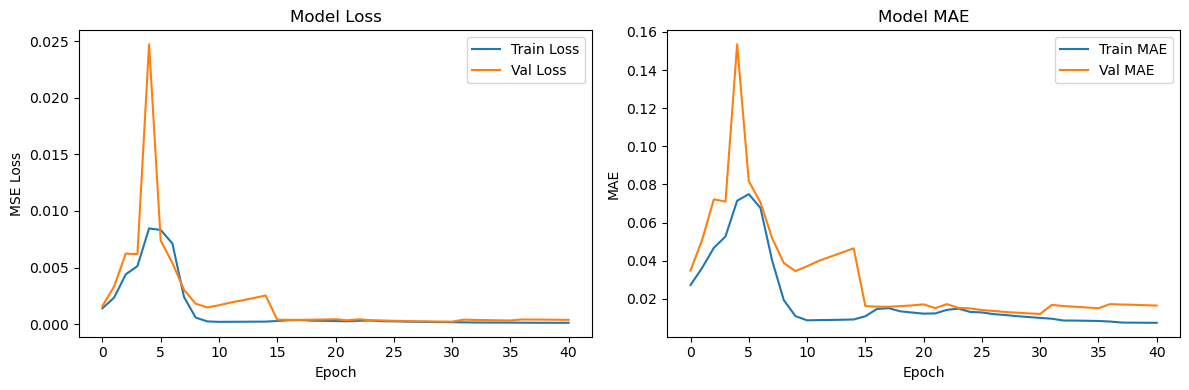

In [41]:
# ── STEP 4: Plot training history ────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
# ── STEP 5: Prepare test sequences ──────────────────────────────
# Need the last 90 days of training data to seed test sequences
past_90_days = train_data[-90:]
test_input = np.concatenate([past_90_days, test_data], axis=0)

X_test_data, y_test_data = [], []
for i in range(90, len(test_input)):
    X_test_data.append(test_input[i-90:i, 0])
    y_test_data.append(test_input[i, 0])

X_test_data = np.array(X_test_data)
y_test_data = np.array(y_test_data)
X_test_data = np.reshape(X_test_data, (X_test_data.shape[0], X_test_data.shape[1], 1))

print(f'Test X shape: {X_test_data.shape}')

Test X shape: (566, 90, 1)


In [43]:
# ── STEP 6: Predict & inverse transform ──────────────────────────
predictions = lstm_model.predict(X_test_data)

# Scale back to real price values
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test_data.reshape(-1, 1))

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step 


In [52]:
lstm_model.save("saved_stock_model.h5")

In [45]:
# ── STEP 7: Evaluation metrics ───────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae  = mean_absolute_error(y_test_actual, predictions)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')
print(f'MAPE : {mape:.2f}%')

RMSE : 14.11
MAE  : 11.76
MAPE : 4.97%


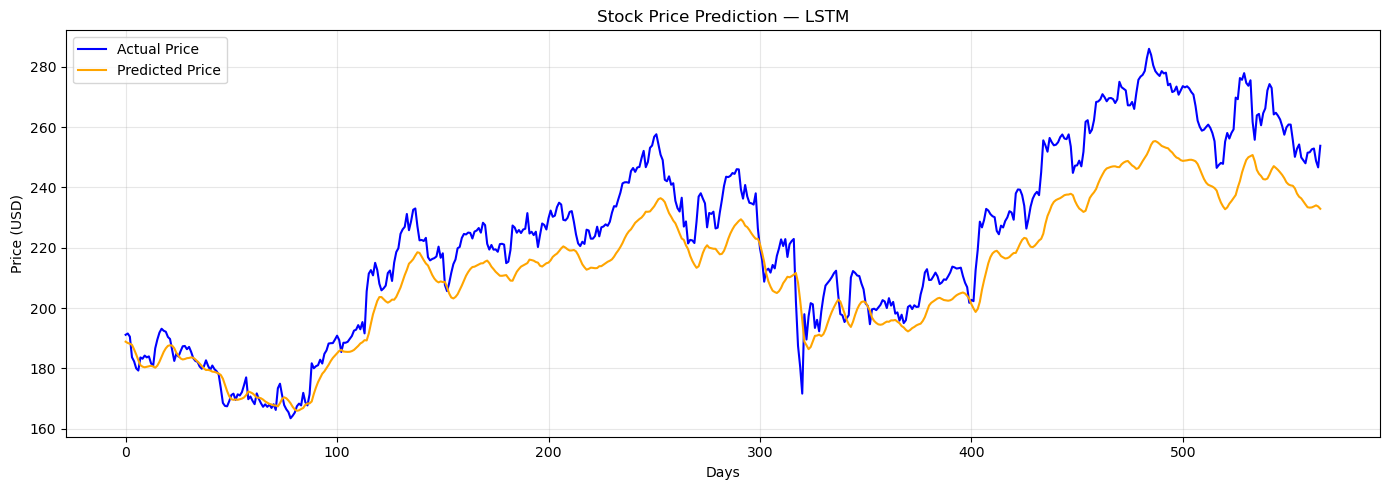

In [46]:
# ── STEP 8: Final plot — actual vs predicted ─────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(predictions,   label='Predicted Price', color='orange', linewidth=1.5)
plt.title('Stock Price Prediction — LSTM')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

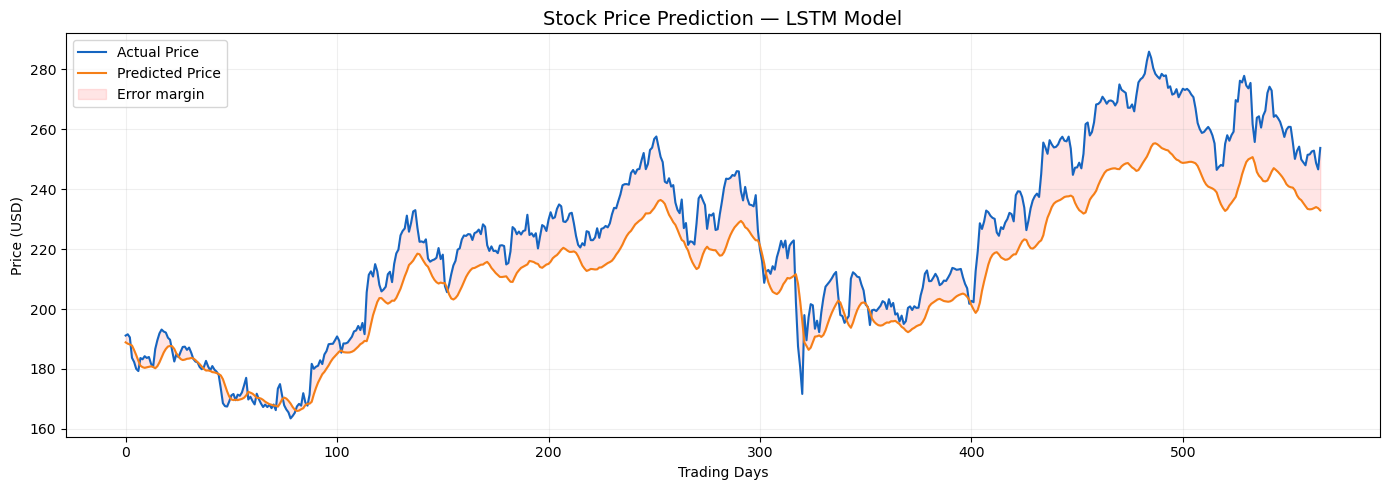

In [47]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, label='Actual Price', color='#1565C0', linewidth=1.5)
plt.plot(predictions,   label='Predicted Price', color='#F57F17', linewidth=1.5)
plt.fill_between(range(len(y_test_actual)),
                 y_test_actual.flatten(),
                 predictions.flatten(),
                 alpha=0.1, color='red', label='Error margin')
plt.title('Stock Price Prediction — LSTM Model', fontsize=14)
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('prediction_plot.png', dpi=150)
plt.show()

### Conclusion

In this project, an LSTM-based deep learning model was developed to predict stock prices using historical time-series data. The model was able to successfully learn and capture the overall trend of the stock market, as observed in the comparison between actual and predicted values. This demonstrates the effectiveness of LSTM networks in handling sequential data and identifying long-term dependencies.

However, the model showed limitations in accurately predicting sudden price fluctuations and short-term volatility. The predictions were smoother and slightly underestimated the actual values, indicating that the model can be further improved. These limitations may be due to the use of limited features and a relatively simple model architecture.

Overall, this project provides a strong foundation for understanding time-series forecasting using deep learning. Future improvements can include adding more features such as technical indicators, tuning model parameters, and experimenting with more advanced architectures to enhance prediction accuracy.

In [51]:
import pickle

pickle.dump(lstm_model, open("model.pkl", "wb"))